# Tutorial: Cross-Entropy Benchmarking (XEB) with `errorgnomark`

Welcome to the Cross-Entropy Benchmarking (XEB) tutorial for the `errorgnomark` framework. This notebook provides a comprehensive walkthrough of the XEB workflow, inspired by the structure of a demonstration script.

We will explore everything from defining a custom hardware gate set to running a fully automated, end-to-end experiment that yields a final fidelity benchmark.

### Learning Objectives:

*   **Part 1: Setup & Configuration:** Initialize the quantum engine, a simulated backend, and a custom native gate set based on specific hardware capabilities.
*   **Part 2: Circuit Generation & Compilation:** See how to generate abstract (logical) circuits and then compile them down to the defined native gate set.
*   **Part 3: Bulk Circuit Generation:** Learn how to use the framework as a powerful tool to generate large batches of circuits for extensive experiments.
*   **Part 4: Automated End-to-End Experiment:** Execute the entire XEB workflow with a single command, from circuit execution to data analysis, plotting, and final fidelity extraction.

## Setup: Imports, Custom Gates, and Engine Initialization

First, we import all necessary components. We then define a custom native gate set. This is a critical step that tells the framework's compiler which gates are available on our target hardware. The `CUSTOM_NATIVE_GATES` dictionary maps gate names to the number of qubits they act on.

Finally, we initialize a `DummyBackend` to simulate a noisy quantum computer and wrap it in a `QuantumEngine`.

In [1]:
import numpy as np
import logging
import matplotlib.pyplot as plt

# ================================================================================
# Step 1: Directly import the required library components
# Assumes the 'errorgnomark' library is already installed.
# ================================================================================
from egm.engine import QuantumEngine
from egm.core.backends.dummy_backend_xeb import DummyBackend
from egm.experiments.benchmarking.xeb import StandardXEBExperiment, InterleavedXEBExperiment
from egm.core.circuits.circuit import Gate

# Configure logging to be informative
logging.basicConfig(level=logging.INFO)

# ================================================================================
# Step 2: Define the native gate set
# ================================================================================
# This gate set defines the capabilities of our target hardware.
# 'sx': Square-root of X gate (Rx(pi/2))
# 'rz': Arbitrary Z-rotation
# 'cz': Controlled-Z gate
# 'id': Identity gate
CUSTOM_NATIVE_GATES = {
    'id': 1, 
    'sx': 1, 
    'rz': 1, 
    'cz': 2
}

# ================================================================================
# Step 3: Initialize the Engine
# ================================================================================
# Use a dummy backend to simulate noisy hardware
backend = DummyBackend(cycle_fidelity=0.97, spam_error=0.001)

# Initialize the Quantum Engine with this backend
engine = QuantumEngine(backend)

print(f"\nEngine initialized with '{backend.name}' (Cycle Fidelity p = {backend.cycle_fidelity:.3f}). Expected EPC ≈ {1 - backend.cycle_fidelity:.4f}")

[INFO] QuantumEngine initialized with backend 'DummyBackend' and is ready.


DummyBackend initialized with a phenomenological model for XEB:
  Cycle Fidelity (p) = 0.97
  SPAM Error = 0.001 -> Fidelity scaling factor = 0.999

Engine initialized with 'DummyBackend' (Cycle Fidelity p = 0.970). Expected EPC ≈ 0.0300


## Part 1: Circuit Generation & Compilation Showcase

This section demonstrates the core circuit generation capabilities. We will:
1.  Generate a *logical* XEB circuit, which uses abstract gates like `fSim`.
2.  Compile that same logical circuit into our `CUSTOM_NATIVE_GATES`.
3.  Generate an *interleaved* circuit, where a specific gate of interest is inserted for characterization.

### 1a. Generate a Logical Circuit

In [2]:
print(">>> 1a. Generating a logical 2-qubit XEB circuit (using abstract fSim gates)...\n")

# The default gate_set="universal_xeb" uses fSim gates, which are logical/abstract.
logical_exp = StandardXEBExperiment(qubits=[0, 1])
logical_circuit = logical_exp.generate_single_circuit(depth=2, seed=1) # Use a fixed seed for reproducibility

print("Circuit diagram (logical gates, uncompiled):")
logical_circuit.draw()

>>> 1a. Generating a logical 2-qubit XEB circuit (using abstract fSim gates)...

Circuit diagram (logical gates, uncompiled):
q0:     ┤RZ(4…├┤ SX  ├┤RZ(2…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(1…├───●───┤RZ(4…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(5…├┤RZ(5…├┤ SX  ├┤RZ(0…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(3…├── M ──
q1:     ┤RZ(0…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(3…├───●───┤RZ(4…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(1…├┤RZ(1…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(4…├── M ──


### 1b. Compile to Custom Native Gates

In [3]:
print(">>> 1b. Compiling the logical circuit to your custom native gate set...\n")

# We now create an experiment instance that uses the custom native gates.
# The compiler will decompose the logical fSim gates into this native set.
native_exp = StandardXEBExperiment(
    qubits=[0, 1],
    native_gates=list(CUSTOM_NATIVE_GATES.keys())
)
compiled_circuit = native_exp.generate_single_circuit(depth=2, seed=1) # Use same seed to compile the same logical circuit

print("Circuit diagram (compiled to your custom native basis):")
compiled_circuit.draw()

>>> 1b. Compiling the logical circuit to your custom native gate set...

Circuit diagram (compiled to your custom native basis):
q0:     ┤RZ(4…├┤ SX  ├┤RZ(2…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(1…├───●───┤RZ(4…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(5…├┤RZ(5…├┤ SX  ├┤RZ(0…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(3…├── M ──
q1:     ┤RZ(0…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(3…├───●───┤RZ(4…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(1…├┤RZ(1…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(4…├── M ──


### 1c. Generate an Interleaved Circuit

In [4]:
print(">>> 1c. Generating an Interleaved XEB circuit with a CZ gate...\n")

# This demonstrates interleaving a native two-qubit gate (CZ).
interleaved_gate = Gate('cz', qubits=[0, 1])
interleaved_exp = InterleavedXEBExperiment(
    qubits=[0, 1],
    interleaved_gate=interleaved_gate)
interleaved_circuit = interleaved_exp.generate_single_circuit(depth=2, seed=2)

print(f"Compiled circuit with '{interleaved_gate.name}' gate interleaved on qubits {interleaved_gate.qubits}:")
interleaved_circuit.draw()

>>> 1c. Generating an Interleaved XEB circuit with a CZ gate...

Compiled circuit with 'cz' gate interleaved on qubits [0, 1]:
q0:     ┤RZ(2…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(4…├───●───┤RZ(4…├┤ SX  ├┤RZ(2…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(2…├┤RZ(2…├┤ SX  ├┤RZ(2…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(2…├── M ──
q1:     ┤RZ(0…├┤ SX  ├┤RZ(0…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(2…├───●───┤RZ(3…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(0…├┤RZ(0…├┤ SX  ├┤RZ(1…├┤RZ(-…├┤ SX  ├┤RZ(-…├┤RZ(1…├── M ──


## Part 2: Bulk Circuit Generation for Experiments

In a real-world scenario, you need to run many different random circuits for many different sequence depths. This section shows how to use the framework to generate this entire set of circuits in one go. These circuits are fully compiled and ready to be executed on the target backend.

In [5]:
print("="*80)
print("// PART 2: BULK CIRCUIT GENERATION FOR EXPERIMENTS")
print("="*80)
print("\nThis demonstrates using the framework as a 'circuit generator' for large-scale")
print("experiments, all compiled to your custom native gate set.\n")

bulk_depths = [10, 20, 30, 40, 50]
circs_per_depth = 20

# This experiment is configured to use the custom native gates specified earlier.
bulk_exp = StandardXEBExperiment(
    qubits=[0, 1, 2, 3],
    depths=bulk_depths,
    circuits_per_depth=circs_per_depth,
    native_gates=list(CUSTOM_NATIVE_GATES.keys())
)

# The .circuits() method generates the full list of circuit objects.
all_circuits = bulk_exp.circuits()

print(f"SUCCESS: Generated a total of {len(all_circuits)} circuits for depths {bulk_depths}.")
print("These circuit objects are compiled to your native basis and can be exported or run.")

// PART 2: BULK CIRCUIT GENERATION FOR EXPERIMENTS

This demonstrates using the framework as a 'circuit generator' for large-scale
experiments, all compiled to your custom native gate set.

SUCCESS: Generated a total of 100 circuits for depths [10, 20, 30, 40, 50].
These circuit objects are compiled to your native basis and can be exported or run.


## Part 3: Automated End-to-End Experiment

This is the culmination of the workflow. We define a `StandardXEBExperiment` with all the necessary parameters: qubits, depths, circuits per depth, and our custom native gate set. 

Then, with a single call to the `.run()` method, the framework will:
1.  Generate all the necessary circuits.
2.  Execute them on the provided `engine`'s backend.
3.  Collect the measurement results (bitstring probabilities).
4.  Perform both XEB and Speckle Purity Benchmarking (SPB) analysis.
5.  Fit the data to an exponential decay model to extract the fidelity.
6.  Generate and display plots of the results.
7.  Return a dictionary containing all raw and analyzed data.

[INFO] --- Running Dual Analysis Standard XEB on Qubits [0, 1] ---
[INFO] Generated 120 circuits. Executing on backend...
[INFO] Executing 120 circuits with 8096 shots each on backend 'DummyBackend'...
[INFO]   ... processing circuit 10/120
[INFO]   ... processing circuit 20/120
[INFO]   ... processing circuit 30/120
[INFO]   ... processing circuit 40/120
[INFO]   ... processing circuit 50/120



Running a full, automated XEB experiment...
Executing on backend... Plot will appear upon completion.


[INFO]   ... processing circuit 60/120
[INFO]   ... processing circuit 70/120
[INFO]   ... processing circuit 80/120
[INFO]   ... processing circuit 90/120
[INFO]   ... processing circuit 100/120
[INFO]   ... processing circuit 110/120
[INFO]   ... processing circuit 120/120
[INFO] Execution complete.
[INFO] Generating dual analysis plot...


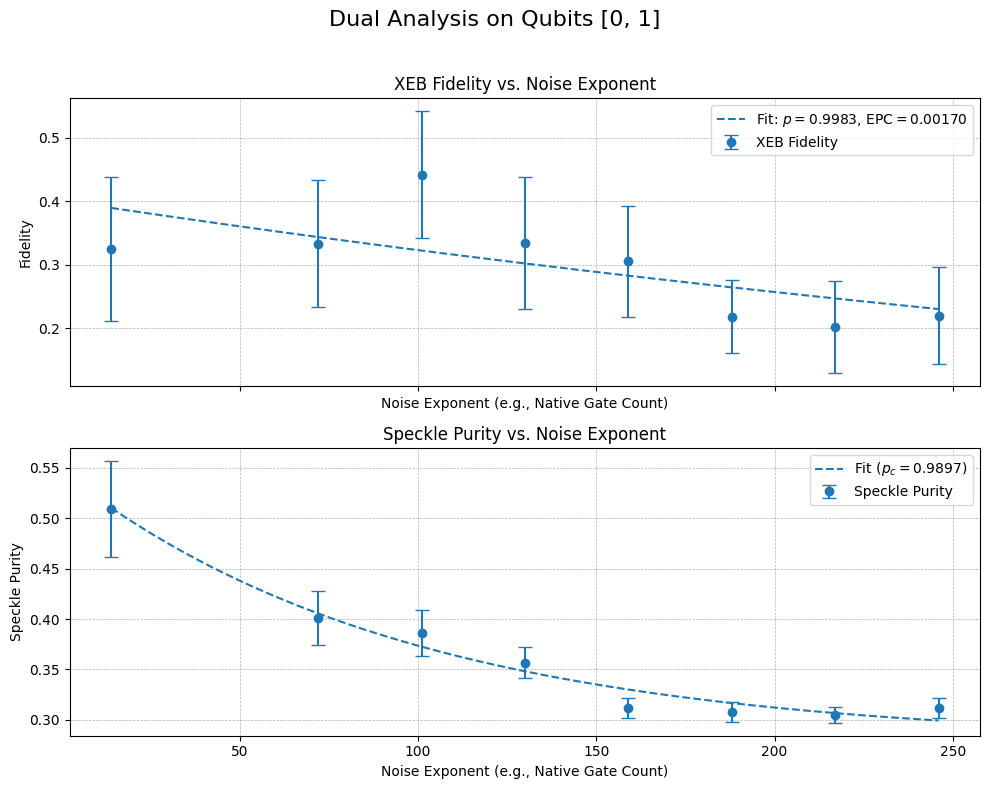


--- Analysis Complete ---
Fitted Error Per Clifford (EPC) from XEB: 0.00170
Fitted Purity Decay Parameter (p_c) from SPB: 0.98971

DEMO COMPLETE: Experiment finished successfully.


In [11]:
# ===================================================================
# PART 3: AUTOMATED END-TO-END EXPERIMENT
# ===================================================================
print("\nRunning a full, automated XEB experiment...")

# Define and configure the experiment to use the custom native gates
automated_exp = StandardXEBExperiment(
    qubits=[0, 1],
    depths=[0, 4, 6, 8, 10, 12, 14, 16],
    circuits_per_depth=15,
    seed=42,
    native_gates=list(CUSTOM_NATIVE_GATES.keys())
)

print("Executing on backend... Plot will appear upon completion.")

# The .run() method handles circuit generation, execution, and analysis
results = automated_exp.run(engine, shots=8096)

print("\n--- Analysis Complete ---")

# Extract and print the key benchmark results from the returned dictionary.
epc = results['xeb_analysis']['fit_results']['epc']

# CORRECTED: Access the 'p_c' key provided by your spb.py file
p_val = results['spb_analysis']['fit_results']['p_c'] 

print(f"Fitted Error Per Clifford (EPC) from XEB: {epc:.5f}")
# Updated the print statement to reflect the variable name 'p_c'
print(f"Fitted Purity Decay Parameter (p_c) from SPB: {p_val:.5f}")

print("\n===================================================================")
print("DEMO COMPLETE: Experiment finished successfully.")
print("===================================================================")